# HBAF: Bayesian adaptive expert fusion

Can a compact posterior over local expert competence improve a calibrated TabM parent under experiment shift?

This is a new **exploratory development** experiment motivated by the failure of identifiable ordered latent states. All earlier negative results remain preserved. The two experts are TabM and Gaussian Naive Bayes; the genuinely Bayesian component is a hierarchical posterior over their input-dependent fusion weights. This does not invent hierarchical stacking: the methodological reference is [Yao et al., Bayesian hierarchical stacking](https://arxiv.org/abs/2101.08954).

Only the 563 development paths from 11 experiments are used. Internal and cross-machine labels are not loaded. The five original seeds and three outer experiment-disjoint folds are retained. Full-route inference is assessed at 100%; no early-monitoring claim is made for this terminal-only fusion experiment. All scale estimation, calibration and threshold selection occur inside each assessment boundary.

In [1]:
from __future__ import annotations
from pathlib import Path
from collections.abc import Mapping, Sequence
import os, json, time, hashlib, warnings, gc
for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                 "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"
import cloudpickle
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown
from scipy.optimize import minimize, minimize_scalar
from scipy.special import expit, logit, logsumexp
from numpy.polynomial.hermite import hermgauss
from scipy.linalg import cho_factor, cho_solve
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (matthews_corrcoef, average_precision_score,
    roc_auc_score, f1_score, log_loss, brier_score_loss)
from tabm import TabM
import torch
from torch.utils.data import DataLoader, TensorDataset
torch.set_num_threads(1)
CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (CWD, *CWD.parents)
    if (path / "notebooks").is_dir() and (path / "dataset").is_dir())
FONT_FAMILY = ("Times New Roman" if "Times New Roman" in font_manager.get_font_names()
               else "DejaVu Serif")
for folder in ("figures/generated", "dataset/predictions", "dataset/protocols"):
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)


In [2]:
TABLES, FIGURES = PROJECT_ROOT / "artifacts", PROJECT_ROOT / "figures" / "generated"
MODEL_DIR = PROJECT_ROOT / "dataset" / "models" / "HBAF_refinement"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SEEDS = (20260807, 20260817, 20260827, 20260837, 20260847)
PRIMARY_SEED = SEEDS[0]
PREFIXES = np.array([0.25, 0.50, 0.75, 1.00])
EPSILON, FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 1e-6, 18, 20, 350
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
get_ipython().config.InlineBackend.print_figure_kwargs = {"bbox_inches": None}
mpl.rcParams.update({"font.family": FONT_FAMILY, "font.size": FONT_SIZE,
    "axes.labelsize": 18, "axes.titlesize": 20, "xtick.labelsize": 18,
    "ytick.labelsize": 18, "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True})
TABM_CONFIGS = [
    {"hidden": 64, "blocks": 2, "k": 4, "dropout": .1, "lr": .001},
    {"hidden": 96, "blocks": 3, "k": 8, "dropout": .2, "lr": .0005}]
EXPERT_CONFIGS = {"TabM": TABM_CONFIGS,
    "GaussianNB": [{"var_smoothing": 1e-9}, {"var_smoothing": 1e-7}]}
CURRENT_MODELS = ["HBAF", "TabM calibrated", "GaussianNB calibrated",
    "Global learned fusion", "Equal fusion", "MAP gate", "No hierarchy", "Raw TabM"]

In [3]:
def display_grouped_tables(frame: pd.DataFrame, identifiers: Sequence[str],
                           column_groups: Mapping[str, Sequence[str]]) -> None:
    """Display every row and metric, without truncated scientific tables."""
    flat = [c for cols in column_groups.values() for c in cols]
    assert len(flat) == len(set(flat))
    assert set(flat) == set(frame) - set(identifiers)
    assert frame[list(identifiers)].notna().all().all()
    with pd.option_context("display.max_rows", None, "display.max_columns", None,
                           "display.max_colwidth", None, "display.width", None):
        for title, columns in column_groups.items():
            compact = frame[list(identifiers) + list(columns)].copy()
            for column in columns:
                if pd.api.types.is_float_dtype(compact[column]):
                    compact[column] = compact[column].map(
                        lambda x: "NA" if not np.isfinite(x)
                        else f"{0.0 if abs(x) < .00005 else x:.4f}".replace("-", "−"))
            display(Markdown(f"#### {title}"))
            display(compact.reset_index(drop=True))

## Development support and retained failure

Which evidence can support a two-expert Bayesian layer without unidentifiable degradation states?

In [4]:
contract = json.loads((PROJECT_ROOT / "dataset/unified/preprocessing_contract.json").read_text())
candidate_features = contract["candidate_static_features"]
categorical_features = contract["categorical_model_features"]
ordered = pd.read_parquet(PROJECT_ROOT / "dataset/processed/causal_prefix_features.parquet",
    filters=[("split", "==", "train")]).sort_values(["cutting_path_id", "prefix_fraction"])
path_meta = ordered.drop_duplicates("cutting_path_id").reset_index(drop=True)
path_ids = path_meta.cutting_path_id.astype(str).to_numpy()
groups = path_meta.experiment_group_id.astype(str).to_numpy()
y_all = path_meta.InterventionRequired.to_numpy(int)
X_static = ordered[candidate_features].to_numpy(np.float32).reshape(
    len(path_meta), 4, len(candidate_features))
X_categories = ordered[categorical_features].astype("string").fillna("<NA>").to_numpy().reshape(
    len(path_meta), 4, len(categorical_features))
train_indices = np.arange(len(path_meta))
assert len(path_meta) == 563 and len(np.unique(groups)) == 11
assert ordered["split"].eq("train").all()
sample = path_meta.groupby("experiment_group_id", sort=True).agg(
    Paths=("cutting_path_id", "size"), Intervention=("InterventionRequired", "sum"))
sample["Intervention share"] = sample.Intervention / sample.Paths
display_grouped_tables(sample.reset_index(), ["experiment_group_id"],
    {"Development sample": ["Paths", "Intervention", "Intervention share"]})

#### Development sample

,experiment_group_id,Paths,Intervention,Intervention share
0,imi_vmx30ui::dataset11,64,0,0.0000
1,imi_vmx30ui::dataset12,64,0,0.0000
2,imi_vmx30ui::dataset14,64,48,0.7500
3,imi_vmx30ui::dataset15,64,54,0.8438
4,imi_vmx30ui::dataset16,64,0,0.0000
5,imi_vmx30ui::dataset17,27,1,0.0370
6,imi_vmx30ui::dataset18,64,0,0.0000
7,imi_vmx30ui::dataset2,12,12,1.0000
8,imi_vmx30ui::dataset4,12,12,1.0000
9,imi_vmx30ui::dataset6,64,0,0.0000


Experiments are the independent resampling units. Homogeneous experiments provide little information for identifying three ordered risk states. This experiment instead estimates relative expert competence, with an unseen-experiment effect integrated out.

In [5]:
old = pd.read_csv(TABLES / "model04_development_summary.csv")
negative = old[old.variant.isin(["Parent — TabM", "HBAF — Full", "HBAF − Bayesian"])]
display_grouped_tables(negative[["variant", "n", "MCC", "PR-AUC", "Brier", "NLL"]],
    ["variant", "n"], {"Retained ordered-state result": ["MCC", "PR-AUC", "Brier", "NLL"]})

#### Retained ordered-state result

,variant,n,MCC,PR-AUC,Brier,NLL
0,Parent — TabM,563,0.6534,0.8373,0.1199,0.4278
1,HBAF − Bayesian,563,0.6534,0.8373,0.1199,0.4278
2,HBAF — Full,563,0.6534,0.8373,0.1199,0.4278


The previous Full model equalled its parent and its Bayesian-removed control. That negative result is retained and is not treated as evidence for the new mechanism.

## Prospective exploratory protocol

For assessment groups A, every base model, selector, calibrator and fusion layer is fitted in T=D\\A. Fusion training uses calibrated base predictions cross-fitted inside T. Thresholds use an additional meta cross-fit: a held B is predicted by a gate trained only on W=T\\B, whose expert features are themselves cross-fitted within W. No globally assembled OOF predictions are used to fit the new gate.

The competence covariates are entropy difference and expert disagreement. Each terminal cutting path enters the Bernoulli gate likelihood once. The empirical-Bayes prior scales are estimated from training evidence; there are no hand-assigned fusion coefficients. The uncertainty is conditional Laplace uncertainty in the fusion layer, including a new experiment effect, not full uncertainty in pretrained experts.

In [6]:
protocol = {"name": "HBAF", "date": "2026-09-17",
    "status": "prospectively specified exploratory refinement",
    "seeds": list(SEEDS), "outer_folds": 3, "meta_folds": 2,
    "base_inner_folds": 2, "checkpoint": 1.0, "models": CURRENT_MODELS,
    "gate_covariates": ["entropy difference", "absolute expert disagreement"],
    "gate_likelihood": "one Bernoulli observation per cutting path",
    "prior": "normal coefficients and experiment effects; training-only Laplace evidence scales",
    "log_scale_numerical_bounds": [-4.0, 2.0], "expanded_bounds": [-8.0, 4.0], "exact_tau_zero_candidate": True, "exact_coefficient_zero_candidate": True, "quadrature_order": 31, "quadrature_check": "61 with adaptive integration fallback",
    "primary": ["MCC", "PR-AUC", "Macro-F1"], "benefit": ["Brier", "NLL"],
    "predictive_harm_margins": {"MCC": .01, "PR-AUC": .005, "Macro-F1": .01},
    "practical_gains": {"Brier": .002, "NLL": .005},
    "bootstrap_draws": 5000, "independent_unit": "experiment",
    "all_previous_attempts_retained": True, "locked_outcomes_used": False}
protocol_path = PROJECT_ROOT / "dataset" / "protocols" / "hbaf.json"
if protocol_path.exists():
    assert json.loads(protocol_path.read_text()) == protocol
else:
    protocol_path.write_text(json.dumps(protocol, indent=2))

## Matched discriminative experts

The feature contract and expert families follow Notebook 03. Each fitting set independently determines missing-value removal, constants, duplicates, MI Top 64, imputation, scaling and categories. The parent includes the same checkpoint-specific Platt calibration as the competitive comparator.

In [7]:
class CheckpointPlatt:
    """Four checkpoint-specific logistic calibration maps."""
    def fit(self, target: np.ndarray, probability: np.ndarray):
        self.models_ = []
        for step in range(probability.shape[1]):
            score = logit(np.clip(probability[:, step], 1e-6, 1 - 1e-6)).reshape(-1, 1)
            model = LogisticRegression(C=1.0, max_iter=2000, random_state=PRIMARY_SEED)
            self.models_.append(model.fit(score, target))
        return self

    def transform(self, probability: np.ndarray) -> np.ndarray:
        calibrated = np.zeros_like(probability, dtype=float)
        for step, model in enumerate(self.models_):
            score = logit(np.clip(probability[:, step], 1e-6, 1 - 1e-6)).reshape(-1, 1)
            calibrated[:, step] = model.predict_proba(score)[:, 1]
        return calibrated

def group_weights(index: np.ndarray) -> np.ndarray:
    """Give every fit experiment equal total contribution."""
    local_groups = groups[index]
    counts = pd.Series(local_groups).value_counts()
    weights = len(index) / (len(counts) * pd.Series(local_groups).map(counts).to_numpy())
    assert np.isclose(weights.mean(), 1.0)
    return weights.astype(np.float32)

In [8]:
def exact_duplicate(candidate: np.ndarray, reference: np.ndarray) -> bool:
    """Identify exactly duplicated fold-training feature trajectories."""
    return bool(np.array_equal(candidate, reference))

In [9]:
class FusionSelector:
    """Train-fold-only cleaning, exact deduplication, MI Top 64 and scaling."""
    def __init__(self, max_features: int = 64):
        self.max_features = int(max_features)

    def fit(self, indices: np.ndarray):
        values = X_static[indices]
        flat = values.reshape(-1, values.shape[-1])
        finite_count = np.isfinite(flat).sum(axis=0)
        valid_indices = np.flatnonzero(finite_count > 0)
        observed = flat[:, valid_indices]
        medians = np.nanmedian(observed, axis=0)
        filled = np.where(np.isfinite(observed), observed, medians)
        nonconstant = np.var(filled, axis=0) > 1e-12
        valid_indices = valid_indices[nonconstant]
        filled = filled[:, nonconstant]
        repeated_target = np.repeat(y_all[indices], len(PREFIXES))
        mi = mutual_info_classif(
            filled, repeated_target,
            discrete_features=False, random_state=PRIMARY_SEED,
        )
        ranking = sorted(range(len(valid_indices)), key=lambda index: (-mi[index], candidate_features[valid_indices[index]]))
        selected, selected_local = [], []
        for local_index in ranking:
            candidate = filled[:, local_index]
            if any(exact_duplicate(candidate, filled[:, prior]) for prior in selected_local):
                continue
            selected.append(valid_indices[local_index]); selected_local.append(local_index)
            if len(selected) == self.max_features:
                break
        assert len(selected) == self.max_features
        self.indices_ = np.asarray(selected, dtype=int)
        self.names_ = [candidate_features[index] for index in self.indices_]
        return self._fit_statistics(indices)

In [10]:
def _fit_selector_statistics(self, indices: np.ndarray):
    values = X_static[indices][:, :, self.indices_]
    flat = values.reshape(-1, values.shape[-1])
    self.median_ = np.nanmedian(flat, axis=0)
    clean = np.where(np.isfinite(flat), flat, self.median_)
    self.center_ = np.median(clean, axis=0)
    q75, q25 = np.percentile(clean, [75, 25], axis=0)
    self.scale_ = np.where(q75 - q25 > 1e-9, q75 - q25, 1.0)
    self.missing_columns_ = np.flatnonzero((~np.isfinite(flat)).any(axis=0))
    self.category_levels_ = []
    for feature_index in range(X_categories.shape[-1]):
        levels = sorted(np.unique(X_categories[indices, :, feature_index].astype(str)))
        self.category_levels_.append(levels)
    return self

FusionSelector._fit_statistics = _fit_selector_statistics

In [11]:
def _transform_selector(self, indices: np.ndarray) -> dict[str, object]:
    values = X_static[indices][:, :, self.indices_].astype(np.float32)
    missing = ~np.isfinite(values)
    clean = np.where(missing, self.median_, values)
    indicators = missing[:, :, self.missing_columns_].astype(np.float32)
    ordinal = np.zeros(X_categories[indices].shape, dtype=np.float32)
    for feature_index, levels in enumerate(self.category_levels_):
        mapping = {level: position for position, level in enumerate(levels)}
        ordinal[:, :, feature_index] = np.vectorize(lambda value: mapping.get(str(value), -1))(
            X_categories[indices, :, feature_index]
        )
    imputed = np.concatenate([clean, indicators, ordinal], axis=2).astype(np.float32)
    scaled_numeric = ((clean - self.center_) / self.scale_).astype(np.float32)
    scaled = np.concatenate([scaled_numeric, indicators, ordinal], axis=2).astype(np.float32)
    native = np.concatenate([values, indicators, ordinal], axis=2).astype(np.float32)
    bayesian_width = min(12, clean.shape[2])
    bayesian = np.stack([part for feature_index in range(bayesian_width)
                         for part in (clean[:, :, feature_index],
                                      missing[:, :, feature_index].astype(np.float32))], axis=2)
    return {"imputed": imputed, "scaled": scaled, "native": native,
            "bayesian": bayesian.astype(np.float32),
            "selected_names": self.names_, "cat_levels": self.category_levels_}

FusionSelector.transform = _transform_selector

In [12]:
class FusionTabM:
    """Official TabM mini-ensemble with explicit inner-fold monitoring."""
    def __init__(self, config: dict, seed: int):
        self.config, self.seed = config, int(seed)

    def fit(self, values: np.ndarray, target: np.ndarray, path_weights: np.ndarray,
            monitor_values=None, monitor_target=None, monitor_weight=None,
            fixed_epochs: int | None = None):
        torch.manual_seed(self.seed); np.random.seed(self.seed)
        flat = values.reshape(-1, values.shape[-1]); flat_target = np.repeat(target, 4).astype(np.float32)
        flat_weight = np.repeat(path_weights / 4, 4).astype(np.float32)
        self.model_ = TabM(n_num_features=flat.shape[1], d_out=1, n_blocks=self.config["blocks"],
                           d_block=self.config["hidden"], dropout=self.config["dropout"],
                           k=self.config["k"], arch_type="tabm-mini", start_scaling_init="random-signs")
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.config["lr"], weight_decay=1e-4)
        self._optimize(flat, flat_target, flat_weight, monitor_values, monitor_target,
                       monitor_weight, fixed_epochs, optimizer)
        return self

In [13]:
def _optimize_tabm(self, values, target, weights, monitor_values,
                       monitor_target, monitor_weight, fixed_epochs, optimizer):
    dataset = TensorDataset(torch.tensor(values), torch.tensor(target), torch.tensor(weights))
    loader = DataLoader(dataset, batch_size=64, shuffle=True,
                        generator=torch.Generator().manual_seed(self.seed))
    monitor_present = monitor_values is not None
    if monitor_present:
        monitor_x = torch.tensor(monitor_values.reshape(-1, monitor_values.shape[-1]))
        monitor_y = torch.tensor(np.repeat(monitor_target, 4).astype(np.float32))
        monitor_w = torch.tensor(np.repeat(monitor_weight / 4, 4).astype(np.float32))
    assert monitor_present or fixed_epochs is not None
    best_loss, best_state, best_epoch, stale = np.inf, None, 0, 0
    max_epochs = int(fixed_epochs) if fixed_epochs is not None else 80
    for epoch in range(max_epochs):
        self.model_.train()
        for batch_value, batch_target, batch_weight in loader:
            optimizer.zero_grad(); logits = self.model_(batch_value, None).squeeze(-1)
            member_loss = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, batch_target[:, None].expand_as(logits), reduction="none"
            ).mean(1)
            loss = (member_loss * batch_weight).mean(); loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model_.parameters(), 1.0); optimizer.step()
        if not monitor_present: continue
        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(monitor_x, None).squeeze(-1)
            expanded = monitor_y[:, None].expand_as(logits)
            losses = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, expanded, reduction="none").mean(1)
            monitor_loss = float((losses * monitor_w).sum() / monitor_w.sum())
        if monitor_loss < best_loss - 1e-4:
            best_loss, best_epoch, stale = monitor_loss, epoch + 1, 0
            best_state = {key: value.detach().clone() for key, value in self.model_.state_dict().items()}
        else: stale += 1
        if stale >= 3: break
    if best_state is not None: self.model_.load_state_dict(best_state)
    self.best_epoch_ = best_epoch if monitor_present else max_epochs

FusionTabM._optimize = _optimize_tabm

In [14]:
def _predict_tabm(self, values: np.ndarray) -> np.ndarray:
    self.model_.eval(); flat = values.reshape(-1, values.shape[-1])
    with torch.no_grad():
        logits = self.model_(torch.tensor(flat), None).squeeze(-1)
        probability = torch.sigmoid(logits).mean(1).numpy()
    return probability.reshape(len(values), 4)

FusionTabM.predict_trajectory = _predict_tabm

In [15]:
SELECTORS, BASE_MODELS, EXPERT_PIPELINES = {}, {}, {}
def representation(indices: np.ndarray) -> FusionSelector:
    """Reuse only an exactly matching fold-training representation."""
    key = tuple(map(int, indices))
    if key not in SELECTORS: SELECTORS[key] = FusionSelector().fit(indices)
    return SELECTORS[key]

def two_groups(indices: np.ndarray, seed: int):
    """Split whole experiments; single-class training uses a prior baseline."""
    assert len(np.unique(groups[indices])) >= 2
    splitter = StratifiedGroupKFold(2, shuffle=True, random_state=seed)
    for fit, hold in splitter.split(np.zeros(len(indices)), y_all[indices], groups[indices]):
        left, right = indices[fit], indices[hold]
        assert set(groups[left]).isdisjoint(groups[right])
        yield left, right

def predict_base(bundle: dict, indices: np.ndarray) -> np.ndarray:
    """Predict four prefixes without fitting on queried observations."""
    if "constant" in bundle: return np.full((len(indices), 4), bundle["constant"])
    transformed = bundle["selector"].transform(indices)
    if bundle["name"] == "TabM":
        return bundle["model"].predict_trajectory(transformed["scaled"])
    values = transformed["imputed"]
    return bundle["model"].predict_proba(values.reshape(-1, values.shape[-1]))[:, 1].reshape(-1, 4)

In [16]:
def fit_base(name: str, config: dict, fit: np.ndarray, seed: int,
             monitor: np.ndarray | None = None, epochs: int | None = None) -> dict:
    """Fit one expert; the query set is excluded from every training decision."""
    key = (name, tuple(fit), seed, json.dumps(config, sort_keys=True),
           None if monitor is None else tuple(monitor), epochs)
    if key in BASE_MODELS: return BASE_MODELS[key]
    started = time.perf_counter()
    if len(np.unique(y_all[fit])) == 1:
        bundle = {"constant": float((y_all[fit].sum() + .5) / (len(fit) + 1)),
                  "name": name, "epochs": 1, "seconds": 0.0}
    else:
        selector = representation(fit)
        data, weights = selector.transform(fit), group_weights(fit)
        if name == "TabM":
            monitor_x = None if monitor is None else selector.transform(monitor)["scaled"]
            model = FusionTabM(config, seed).fit(data["scaled"], y_all[fit], weights,
                monitor_x, None if monitor is None else y_all[monitor],
                None if monitor is None else group_weights(monitor), epochs)
        else:
            values = data["imputed"]
            model = GaussianNB(**config).fit(values.reshape(-1, values.shape[-1]),
                np.repeat(y_all[fit], 4), sample_weight=np.repeat(weights / 4, 4))
        bundle = {"name": name, "selector": selector, "model": model,
            "epochs": int(getattr(model, "best_epoch_", 1)),
            "seconds": time.perf_counter() - started}
    BASE_MODELS[key] = bundle
    return bundle

In [17]:
def selection_scores(target: np.ndarray, probability: np.ndarray,
                     experiment: np.ndarray) -> tuple:
    """Use the existing worst-group, mean-group, Brier selection order."""
    clipped = np.clip(probability, EPSILON, 1 - EPSILON)
    loss = -(target[:, None] * np.log(clipped)
             + (1 - target[:, None]) * np.log1p(-clipped)).mean(1)
    grouped = pd.Series(loss).groupby(experiment).mean()
    return float(grouped.max()), float(grouped.mean()), float(
        np.mean((target[:, None] - probability) ** 2))

def tune_expert(name: str, indices: np.ndarray, seed: int, tag: int) -> dict:
    """Tune and calibrate an expert entirely within its fitting experiments."""
    candidates, location = [], {value: i for i, value in enumerate(indices)}
    for configuration in EXPERT_CONFIGS[name]:
        raw = np.full((len(indices), 4), np.nan)
        budgets = []
        for fit, hold in two_groups(indices, seed + 1009 * tag):
            base = fit_base(name, configuration, fit, seed, monitor=hold)
            positions = [location[value] for value in hold]
            raw[positions] = predict_base(base, hold)
            budgets.append(base["epochs"])
        calibrator = CheckpointPlatt().fit(y_all[indices], raw)
        probability = calibrator.transform(raw)
        candidates.append({"configuration": configuration, "calibrator": calibrator,
            "epochs": int(np.median(budgets)), "raw_oof": raw,
            "scores": selection_scores(y_all[indices], probability, groups[indices])})
    chosen = min(candidates, key=lambda result: result["scores"])
    chosen["bundle"] = fit_base(name, chosen["configuration"], indices, seed,
                                epochs=chosen["epochs"])
    return chosen

In [18]:
def expert_pipeline(indices: np.ndarray, seed: int, tag: int) -> dict:
    """Fit both experts using one fold-local feature cache."""
    key = (tuple(indices), seed, tag)
    if key not in EXPERT_PIPELINES:
        if len(np.unique(y_all[indices])) == 1 or len(np.unique(groups[indices])) < 2:
            prior = float((y_all[indices].sum() + .5) / (len(indices) + 1))
            EXPERT_PIPELINES[key] = {"constant": prior}
        else:
            EXPERT_PIPELINES[key] = {
                name: tune_expert(name, indices, seed, tag) for name in EXPERT_CONFIGS}
    return EXPERT_PIPELINES[key]

def expert_predictions(pipeline: dict, indices: np.ndarray) -> tuple:
    """Return matched terminal calibrated experts and raw parent probability."""
    if "constant" in pipeline:
        value = np.full(len(indices), pipeline["constant"])
        return np.column_stack([value, value]), value
    output, raw_parent = [], None
    for name in EXPERT_CONFIGS:
        fitted = pipeline[name]
        raw = predict_base(fitted["bundle"], indices)
        output.append(fitted["calibrator"].transform(raw)[:, -1])
        if name == "TabM": raw_parent = raw[:, -1]
    return np.clip(np.column_stack(output), EPSILON, 1-EPSILON), raw_parent

In [19]:
CROSSFIT_EXPERTS = {}
def crossfit_experts(indices: np.ndarray, seed: int, tag: int) -> tuple:
    """Construct meta features without the assessed group's labels."""
    key = (tuple(indices), seed, tag)
    if key not in CROSSFIT_EXPERTS:
        probabilities, raw = np.full((len(indices), 2), np.nan), np.full(len(indices), np.nan)
        lookup = {value: position for position, value in enumerate(indices)}
        for fit, hold in two_groups(indices, seed + 503 + tag):
            pipeline = expert_pipeline(fit, seed, tag)
            values, uncalibrated = expert_predictions(pipeline, hold)
            positions = [lookup[value] for value in hold]
            probabilities[positions], raw[positions] = values, uncalibrated
        assert np.isfinite(probabilities).all() and np.isfinite(raw).all()
        CROSSFIT_EXPERTS[key] = (probabilities, raw)
    return CROSSFIT_EXPERTS[key]

## Conditional Bayesian competence model

Let p₀ and p₁ denote the calibrated expert probabilities. The learned gate is w(x)=sigmoid(β₀+β₁[H(p₀)−H(p₁)]+β₂|p₀−p₁|+u_g), with Gaussian coefficient priors and u_g ~ Normal(0,τ²). The Bernoulli probability is (1−w)p₀+w p₁.

The exact posterior curvature is used, with positive-definite Cholesky checks. Empirical-Bayes scales maximize a Laplace marginal likelihood on training-only cross-fitted predictions. Unseen experiment effects are integrated out. A fixed equal mixture is a labelled ablation only. The model learns competence through predictive log likelihood; it is not labelled a separately trained local-risk regressor.

In [20]:
def entropy(probability: np.ndarray) -> np.ndarray:
    """Return binary entropy in nats."""
    p = np.clip(probability, EPSILON, 1-EPSILON)
    return -p * np.log(p) - (1-p) * np.log1p(-p)

def competence_features(probabilities: np.ndarray) -> np.ndarray:
    """Create two outcome-free covariates of relative expert competence."""
    return np.column_stack([
        entropy(probabilities[:, 0]) - entropy(probabilities[:, 1]),
        np.abs(probabilities[:, 0] - probabilities[:, 1])])

def mixture_posterior(theta: np.ndarray, design: np.ndarray,
                      event0: np.ndarray, event1: np.ndarray) -> tuple:
    """Exact objective, gradient and Hessian in non-centred coordinates."""
    eta = design @ theta
    weight = expit(eta)
    responsibility = expit(eta + event1 - event0)
    likelihood = np.logaddexp(-np.logaddexp(0, eta) + event0,
                             -np.logaddexp(0, -eta) + event1)
    value = -likelihood.sum() + .5 * (theta @ theta)
    gradient = design.T @ (weight - responsibility) + theta
    curvature = weight * (1-weight) - responsibility * (1-responsibility)
    hessian = design.T @ (curvature[:, None] * design) + np.eye(len(theta))
    return float(value), gradient, hessian

In [21]:
def posterior_mode(design: np.ndarray, event0: np.ndarray, event1: np.ndarray) -> dict:
    """Find a converged local mode with exact positive-definite curvature."""
    modes = []
    for initial_intercept in (-1.0, 0.0, 1.0):
        initial = np.zeros(design.shape[1]); initial[0] = initial_intercept
        result = minimize(lambda t: mixture_posterior(t, design, event0, event1)[:2],
            initial, jac=True, method="BFGS", options={"gtol": 1e-6, "maxiter": 400})
        value, gradient, hessian = mixture_posterior(result.x, design, event0, event1)
        if np.max(np.abs(gradient)) > 1e-4: continue
        try: factor = cho_factor(hessian)
        except np.linalg.LinAlgError: continue
        logdet = 2 * np.log(np.diag(factor[0])).sum()
        modes.append({"theta": result.x, "value": value, "factor": factor,
            "evidence": -value - .5 * logdet,
            "gradient": float(np.max(np.abs(gradient))),
            "hessian_condition": float(np.linalg.cond(hessian))})
    assert modes, "No verified Laplace mode; model must not be admitted."
    selected = min(modes, key=lambda mode: mode["value"])
    selected["mode_objective_spread"] = float(np.ptp([mode["value"] for mode in modes]))
    return selected

In [22]:
class BayesianCompetenceGate:
    """Conditional Laplace gate, with training-only empirical-Bayes scales."""
    def __init__(self, hierarchy: bool = True):
        self.hierarchy = hierarchy

    def fit(self, probability: np.ndarray, target: np.ndarray, experiment: np.ndarray):
        features = competence_features(probability)
        self.center_ = features.mean(0)
        self.scale_ = np.maximum(features.std(0), 1e-8)
        matrix = np.column_stack([np.ones(len(features)), (features-self.center_)/self.scale_])
        levels, codes = np.unique(experiment, return_inverse=True)
        membership = np.eye(len(levels))[codes]
        clipped = np.clip(probability, EPSILON, 1-EPSILON)
        events = target[:, None] * np.log(clipped) + (1-target[:, None]) * np.log1p(-clipped)
        self._estimate_scales(matrix, membership, events)
        return self

    def design(self, probability: np.ndarray) -> np.ndarray:
        values = competence_features(probability)
        return np.column_stack([np.ones(len(values)), (values-self.center_)/self.scale_])

In [23]:
def _estimate_scales(self, matrix, membership, events):
    """Maximize marginal evidence; no assessment outcome enters this fit."""
    memo = {}
    def evaluate(log_scales):
        scales = np.exp(np.asarray(log_scales))
        prior_sd, tau = float(scales[0]), float(scales[1]) if self.hierarchy else 0.0
        key = tuple(np.round(log_scales, 7))
        if key not in memo:
            design = np.column_stack([prior_sd*matrix, tau*membership]) if self.hierarchy else prior_sd*matrix
            mode = posterior_mode(design, events[:, 0], events[:, 1])
            memo[key] = (mode, prior_sd, tau)
        return memo[key]
    dimensions = 2 if self.hierarchy else 1
    result = minimize(lambda z: -evaluate(z)[0]["evidence"], np.zeros(dimensions),
        method="Powell", bounds=[(-4.0, 2.0)]*dimensions,
        options={"xtol": .02, "ftol": 1e-4, "maxiter": 15})
    if not result.success:
        result = minimize(lambda z: -evaluate(z)[0]["evidence"], result.x,
            method="Powell", bounds=[(-4.0, 2.0)]*dimensions,
            options={"xtol": .01, "ftol": 1e-5, "maxiter": 60})
    at_bound = np.any(result.x < -3.95) or np.any(result.x > 1.95)
    if at_bound:
        result = minimize(lambda z: -evaluate(z)[0]["evidence"], result.x,
            method="Powell", bounds=[(-8.0, 4.0)]*dimensions,
            options={"xtol": .01, "ftol": 1e-5, "maxiter": 60})
    assert result.success, "Empirical-Bayes scale optimizer did not converge."
    mode, prior_sd, tau = evaluate(result.x)
    self.prior_sd_, self.tau_ = prior_sd, tau
    self.beta_ = prior_sd * mode["theta"][:3]
    inverse = cho_solve(mode["factor"], np.eye(len(mode["theta"])))
    self.covariance_ = prior_sd**2 * inverse[:3, :3]
    self.evidence_, self.gradient_ = mode["evidence"], mode["gradient"]
    self.hessian_condition_ = mode["hessian_condition"]
    self.mode_objective_spread_ = mode["mode_objective_spread"]
    self.coefficient_collapsed_ = False
    self.scale_at_boundary_ = bool(np.any(np.isclose(result.x, [-8.0 if at_bound else -4.0], atol=.05))
        or np.any(np.isclose(result.x, [4.0 if at_bound else 2.0], atol=.05)))
    self.parameter_count_ = int(len(mode["theta"]) + dimensions)
BayesianCompetenceGate._estimate_scales = _estimate_scales

In [24]:
def fit_coefficient_boundary(reference, probability, target, experiment, hierarchy=True):
    """Include the exact zero-variance gate boundary in empirical Bayes."""
    import copy
    candidate = copy.deepcopy(reference)
    _, codes = np.unique(experiment, return_inverse=True)
    membership = np.eye(codes.max()+1)[codes]
    p = np.clip(probability, EPSILON, 1-EPSILON)
    events = target[:, None]*np.log(p)+(1-target[:, None])*np.log1p(-p)
    def mode_at(tau):
        return posterior_mode(tau*membership, events[:, 0], events[:, 1])
    optimum = minimize_scalar(lambda z: -mode_at(np.exp(z))["evidence"],
        bounds=(-8, 4), method="bounded", options={"xatol": .005})
    assert optimum.success
    tau = float(np.exp(optimum.x))
    mode, null = mode_at(tau), mode_at(0.0)
    if not hierarchy or null["evidence"] >= mode["evidence"]: mode, tau = null, 0.0
    candidate.hierarchy = bool(tau > 0)
    candidate.prior_sd_, candidate.tau_ = 0.0, tau
    candidate.beta_, candidate.covariance_ = np.zeros(3), np.zeros((3, 3))
    candidate.evidence_, candidate.gradient_ = mode["evidence"], mode["gradient"]
    candidate.hessian_condition_ = mode["hessian_condition"]
    candidate.mode_objective_spread_ = mode["mode_objective_spread"]
    candidate.coefficient_collapsed_ = True
    candidate.hierarchy_collapsed_ = tau == 0.0
    candidate.scale_at_boundary_ = bool(tau > 0 and (optimum.x < -7.95 or optimum.x > 3.95))
    candidate.parameter_count_ = int(len(mode["theta"])+1) if tau else 0
    return candidate


In [25]:
def _gate_predict(self, probability: np.ndarray, quadrature_order: int = 31) -> dict:
    """Integrate parameter and fresh-experiment fusion uncertainty."""
    design = self.design(probability)
    mean = design @ self.beta_
    parameter_variance = np.einsum("ij,jk,ik->i", design, self.covariance_, design)
    assert np.min(parameter_variance) > -1e-8
    variance = np.maximum(parameter_variance, 0) + self.tau_**2
    nodes, weights = hermgauss(quadrature_order)
    samples = expit(mean[:, None] + np.sqrt(2*variance[:, None])*nodes)
    gate = samples @ (weights / np.sqrt(np.pi))
    nodes2, weights2 = hermgauss(61)
    check = expit(mean[:, None] + np.sqrt(2*variance[:, None])*nodes2)
    check_mean = check @ (weights2/np.sqrt(np.pi))
    second = samples**2 @ (weights/np.sqrt(np.pi))
    check_second = check**2 @ (weights2/np.sqrt(np.pi))
    if max(np.max(np.abs(check_mean-gate)), np.max(np.abs(check_second-second))) > 1e-6:
        from scipy.integrate import quad_vec
        moments, error = quad_vec(lambda z: np.vstack([
            expit(mean + np.sqrt(variance)*z),
            expit(mean + np.sqrt(variance)*z)**2]) * np.exp(-z*z/2)/np.sqrt(2*np.pi),
            -10, 10, epsabs=1e-9)
        assert error < 1e-6
        gate, second = moments
    else:
        second = samples**2 @ (weights/np.sqrt(np.pi))
    gate_variance = np.maximum(second - gate**2, 0)
    difference = probability[:, 1] - probability[:, 0]
    predicted = probability[:, 0] + gate*difference
    endpoints = probability[:, :1] + difference[:, None] * expit(
        mean[:, None] + np.sqrt(variance[:, None])*np.array([-1.95996398454, 1.95996398454]))
    return {"probability": np.clip(predicted, EPSILON, 1-EPSILON),
        "map": probability[:, 0] + expit(mean)*difference,
        "uncertainty": np.abs(difference)*np.sqrt(gate_variance),
        "gate_mean": gate, "gate_variance": gate_variance,
        "lower": endpoints.min(1), "upper": endpoints.max(1),
        "parameter_logit_variance": parameter_variance,
        "new_experiment_logit_variance": np.full(len(probability), self.tau_**2)}
BayesianCompetenceGate.predict = _gate_predict

In [26]:
def fit_fusion(probability: np.ndarray, target: np.ndarray, experiment: np.ndarray) -> dict:
    """Fit matched Full, non-hierarchical and global stacking controls."""
    full = BayesianCompetenceGate(True).fit(probability, target, experiment)
    no_hierarchy = BayesianCompetenceGate(False).fit(probability, target, experiment)
    null = fit_coefficient_boundary(no_hierarchy, probability, target, experiment, False)
    if null.evidence_ >= no_hierarchy.evidence_: no_hierarchy = null
    collapsed = no_hierarchy.evidence_ >= full.evidence_
    if collapsed: full = no_hierarchy
    full.hierarchy_collapsed_ = bool(collapsed)
    zero = fit_coefficient_boundary(full, probability, target, experiment)
    if zero.evidence_ >= full.evidence_: full = zero
    result = minimize_scalar(lambda weight: log_loss(target,
        np.clip((1-weight)*probability[:, 0]+weight*probability[:, 1], EPSILON, 1-EPSILON),
        labels=[0, 1]), bounds=(0, 1), method="bounded")
    return {"full": full, "no_hierarchy": no_hierarchy, "global_weight": float(result.x)}

def predict_fusion(fitted: dict, probability: np.ndarray, raw: np.ndarray) -> tuple:
    """Use only inference covariates and marginalize unseen experiment effects."""
    full = fitted["full"].predict(probability)
    weight = fitted["global_weight"]
    output = {"HBAF": full["probability"], "TabM calibrated": probability[:, 0],
        "GaussianNB calibrated": probability[:, 1],
        "Global learned fusion": (1-weight)*probability[:, 0]+weight*probability[:, 1],
        "Equal fusion": probability.mean(1), "MAP gate": full["map"],
        "No hierarchy": fitted["no_hierarchy"].predict(probability)["probability"],
        "Raw TabM": raw}
    return output, full

In [27]:
def choose_threshold(target: np.ndarray, probability: np.ndarray) -> float:
    """Select MCC operating point on triple-excluded meta OOF evidence."""
    candidates = np.unique(np.r_[.05, .95,
        np.quantile(probability, np.linspace(0, 1, 101))])
    scores = np.array([matthews_corrcoef(target, probability >= value)
                       for value in candidates])
    best = np.flatnonzero(np.isclose(scores, scores.max()))
    return float(candidates[best[np.argmin(np.abs(candidates[best]-.5))]])

def meta_predictions(indices: np.ndarray, seed: int, tag: int) -> dict:
    """Hold B out of the full expert-calibration-posterior construction."""
    result = {name: np.full(len(indices), np.nan) for name in CURRENT_MODELS}
    positions = {value: i for i, value in enumerate(indices)}
    for fit, hold in two_groups(indices, seed + 2017 + tag):
        training, _ = crossfit_experts(fit, seed, tag)
        fusion = fit_fusion(training, y_all[fit], groups[fit])
        assessment, raw = expert_predictions(expert_pipeline(fit, seed, tag), hold)
        prediction, _ = predict_fusion(fusion, assessment, raw)
        location = [positions[value] for value in hold]
        for name in CURRENT_MODELS: result[name][location] = prediction[name]
    assert all(np.isfinite(value).all() for value in result.values())
    return result

In [28]:
def predictive_metrics(target: np.ndarray, probability: np.ndarray,
                       prediction: np.ndarray) -> dict:
    """Return the same terminal estimands for every candidate."""
    return {"MCC": matthews_corrcoef(target, prediction),
        "PR-AUC": average_precision_score(target, probability),
        "Macro-F1": f1_score(target, prediction, average="macro"),
        "AUROC": roc_auc_score(target, probability),
        "Brier": brier_score_loss(target, probability),
        "NLL": log_loss(target, np.clip(probability, EPSILON, 1-EPSILON), labels=[0,1])}

PARTITIONS = []
for repeat, seed in enumerate(SEEDS, start=1):
    splitter = StratifiedGroupKFold(3, shuffle=True, random_state=seed)
    for fold, (fit, hold) in enumerate(splitter.split(X_static[:, -1, :1], y_all, groups), 1):
        assert set(groups[fit]).isdisjoint(groups[hold])
        PARTITIONS.append({"repeat": repeat, "seed": seed, "fold": fold,
                           "fit": fit, "hold": hold})
assert len(PARTITIONS) == 15
CURRENT_RECORDS, CURRENT_RUNTIME, CURRENT_COMPONENTS, CURRENT_FITS = [], [], [], []

In [29]:
def outer_record(name: str, part: dict, probability: np.ndarray,
                 threshold: float, posterior: dict) -> pd.DataFrame:
    """Export per-path evidence, uncertainty and exactly matched assessment keys."""
    hold = part["hold"]
    use_posterior = name == "HBAF"
    return pd.DataFrame({"model": name, "repeat": part["repeat"], "seed": part["seed"],
        "outer_fold": part["fold"], "cutting_path_id": path_ids[hold],
        "experiment_group_id": groups[hold], "checkpoint": 1.0,
        "target": y_all[hold], "probability": probability, "threshold": threshold,
        "uncertainty": posterior["uncertainty"] if use_posterior else entropy(probability),
        "gate_mean": posterior["gate_mean"] if use_posterior else np.nan,
        "gate_variance": posterior["gate_variance"] if use_posterior else np.nan,
        "risk_lower": posterior["lower"] if use_posterior else np.nan,
        "risk_upper": posterior["upper"] if use_posterior else np.nan,
        "parameter_logit_variance": posterior["parameter_logit_variance"] if use_posterior else np.nan,
        "new_experiment_logit_variance": posterior["new_experiment_logit_variance"] if use_posterior else np.nan})

def save_current_evidence() -> None:
    """Persist completed assessments silently; never invent unfinished results."""
    pd.concat(CURRENT_RECORDS, ignore_index=True).to_parquet(
        PROJECT_ROOT / "dataset" / "predictions" / "hbaf_current_oof.parquet", index=False)
    pd.DataFrame(CURRENT_RUNTIME).to_csv(TABLES / "hbaf_current_runtime.csv", index=False)
    pd.DataFrame(CURRENT_COMPONENTS).to_csv(TABLES / "hbaf_current_components.csv", index=False)

In [30]:
def run_outer(partition_number: int) -> pd.DataFrame:
    """Fit one complete assessment boundary and report scientific metrics."""
    part = PARTITIONS[partition_number]
    started = time.perf_counter()
    fit, hold, seed, tag = part["fit"], part["hold"], part["seed"], part["fold"]
    training, _ = crossfit_experts(fit, seed, tag)
    calibration = meta_predictions(fit, seed, tag)
    fused = fit_fusion(training, y_all[fit], groups[fit])
    experts = expert_pipeline(fit, seed, tag)
    values, raw = expert_predictions(experts, hold)
    inference_started = time.perf_counter()
    predictions, posterior = predict_fusion(fused, values, raw)
    inference_ms = 1000*(time.perf_counter()-inference_started)/len(hold)
    rows = []
    for name, probability in predictions.items():
        threshold = choose_threshold(y_all[fit], calibration[name])
        record = outer_record(name, part, probability, threshold, posterior)
        CURRENT_RECORDS.append(record)
        rows.append({"Model": name, "Repeat": part["repeat"], "Fold": tag, "n": len(hold),
            **predictive_metrics(y_all[hold], probability, probability >= threshold)})
    elapsed = time.perf_counter()-started
    CURRENT_FITS.append({"partition": part, "experts": experts, "fusion": fused})
    CURRENT_COMPONENTS.append({"repeat": part["repeat"], "fold": tag,
        "prior_sd": fused["full"].prior_sd_, "experiment_sd": fused["full"].tau_,
        "mean_gate": posterior["gate_mean"].mean(),
        "gate_sd": posterior["gate_mean"].std(), "mean_uncertainty": posterior["uncertainty"].mean(),
        "scale_at_boundary": fused["full"].scale_at_boundary_,
        "gradient_norm": fused["full"].gradient_,
        "hessian_condition": fused["full"].hessian_condition_,
        "hierarchy_collapsed": fused["full"].hierarchy_collapsed_,
        "coefficient_collapsed": fused["full"].coefficient_collapsed_,
        "mode_objective_spread": fused["full"].mode_objective_spread_})
    CURRENT_RUNTIME.append({"model": "HBAF", "repeat": part["repeat"], "outer_fold": tag,
        "fit_seconds": elapsed, "inference_ms_per_path": inference_ms,
        "model_size_mb": np.nan, "parameter_count": fused["full"].parameter_count_})
    save_current_evidence()
    return pd.DataFrame(rows)

## Posterior derivative checks

Verify the posterior derivatives and probability mapping on a synthetic numerical fixture before evaluating held-out observations.


In [31]:
from scipy.optimize._numdiff import approx_derivative
_fixture_rng = np.random.default_rng(37)
_fixture_design = _fixture_rng.normal(size=(24, 7))
_fixture_theta = _fixture_rng.normal(size=7)
_fixture_p = _fixture_rng.uniform(.02, .98, (24, 2))
_fixture_y = _fixture_rng.integers(0, 2, 24)
_fixture_events = _fixture_y[:, None]*np.log(_fixture_p) + (1-_fixture_y[:, None])*np.log1p(-_fixture_p)
_fixture_args = (_fixture_design, _fixture_events[:, 0], _fixture_events[:, 1])
_value, _grad, _hessian = mixture_posterior(_fixture_theta, *_fixture_args)
_gradient_numeric = approx_derivative(
    lambda z: mixture_posterior(z, *_fixture_args)[0], _fixture_theta).ravel()
_hessian_numeric = approx_derivative(
    lambda z: mixture_posterior(z, *_fixture_args)[1], _fixture_theta)
assert np.allclose(_grad, _gradient_numeric, atol=1e-6)
assert np.allclose(_hessian, _hessian_numeric, atol=1e-6)

## Development assessment: repeat 1, fold 1

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [32]:
assessment_1 = run_outer(0)
display_grouped_tables(assessment_1, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,1,1,192,0.8847,0.9615,0.9388,0.9855
1,TabM calibrated,1,1,192,0.7813,0.9618,0.8774,0.9856
2,GaussianNB calibrated,1,1,192,0.8810,0.8549,0.9382,0.9668
3,Global learned fusion,1,1,192,0.8352,0.9615,0.9103,0.9855
4,Equal fusion,1,1,192,0.8744,0.9615,0.9330,0.9855
5,MAP gate,1,1,192,0.8951,0.9615,0.9447,0.9855
6,No hierarchy,1,1,192,0.8744,0.9610,0.9330,0.9852
7,Raw TabM,1,1,192,0.8643,0.9618,0.9273,0.9856


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,1,1,192,0.0450,0.1685
1,TabM calibrated,1,1,192,0.0541,0.3439
2,GaussianNB calibrated,1,1,192,0.0432,0.1585
3,Global learned fusion,1,1,192,0.0430,0.1570
4,Equal fusion,1,1,192,0.0441,0.1605
5,MAP gate,1,1,192,0.0475,0.3262
6,No hierarchy,1,1,192,0.0468,0.1672
7,Raw TabM,1,1,192,0.0632,0.2823


## Development assessment: repeat 1, fold 2

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [33]:
assessment_2 = run_outer(1)
display_grouped_tables(assessment_2, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,1,2,192,0.7404,0.9428,0.8673,0.9789
1,TabM calibrated,1,2,192,0.1253,0.9187,0.4503,0.9646
2,GaussianNB calibrated,1,2,192,0.0000,0.7342,0.4286,0.9398
3,Global learned fusion,1,2,192,0.0000,0.9425,0.4286,0.9774
4,Equal fusion,1,2,192,0.7306,0.9464,0.8457,0.9805
5,MAP gate,1,2,192,0.3612,0.9397,0.5819,0.9784
6,No hierarchy,1,2,192,0.7623,0.9411,0.8811,0.9755
7,Raw TabM,1,2,192,0.0000,0.9187,0.4286,0.9646


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,1,2,192,0.0537,0.1651
1,TabM calibrated,1,2,192,0.0690,0.2363
2,GaussianNB calibrated,1,2,192,0.0849,0.2814
3,Global learned fusion,1,2,192,0.0533,0.1608
4,Equal fusion,1,2,192,0.0476,0.1503
5,MAP gate,1,2,192,0.0686,0.2266
6,No hierarchy,1,2,192,0.0682,0.2379
7,Raw TabM,1,2,192,0.0665,0.1945


## Development assessment: repeat 1, fold 3

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [34]:
assessment_3 = run_outer(2)
display_grouped_tables(assessment_3, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,1,3,179,0.6351,0.9633,0.7838,0.9932
1,TabM calibrated,1,3,179,0.7546,0.9216,0.8753,0.9836
2,GaussianNB calibrated,1,3,179,0.0000,0.9448,0.4625,0.9899
3,Global learned fusion,1,3,179,0.7546,0.9216,0.8753,0.9836
4,Equal fusion,1,3,179,0.0000,0.9648,0.4625,0.9935
5,MAP gate,1,3,179,0.1623,0.9216,0.2793,0.9836
6,No hierarchy,1,3,179,0.6351,0.9633,0.7838,0.9932
7,Raw TabM,1,3,179,0.5820,0.9216,0.7412,0.9836


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,1,3,179,0.0404,0.1361
1,TabM calibrated,1,3,179,0.0855,0.2652
2,GaussianNB calibrated,1,3,179,0.0498,0.1570
3,Global learned fusion,1,3,179,0.0855,0.2652
4,Equal fusion,1,3,179,0.0392,0.1361
5,MAP gate,1,3,179,0.0855,0.2651
6,No hierarchy,1,3,179,0.0404,0.1361
7,Raw TabM,1,3,179,0.1423,0.4585


## Development assessment: repeat 2, fold 1

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [35]:
assessment_4 = run_outer(3)
display_grouped_tables(assessment_4, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,2,1,192,0.5344,0.9581,0.6971,0.9839
1,TabM calibrated,2,1,192,0.4580,0.9579,0.6285,0.9838
2,GaussianNB calibrated,2,1,192,0.7323,0.6923,0.8458,0.9130
3,Global learned fusion,2,1,192,0.4685,0.9581,0.6384,0.9839
4,Equal fusion,2,1,192,0.5344,0.9581,0.6971,0.9839
5,MAP gate,2,1,192,0.5344,0.9581,0.6971,0.9839
6,No hierarchy,2,1,192,0.4954,0.9581,0.6630,0.9839
7,Raw TabM,2,1,192,0.6522,0.9579,0.7900,0.9838


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,2,1,192,0.1209,0.3721
1,TabM calibrated,2,1,192,0.1498,0.5099
2,GaussianNB calibrated,2,1,192,0.1142,0.3625
3,Global learned fusion,2,1,192,0.1158,0.3602
4,Equal fusion,2,1,192,0.1209,0.3721
5,MAP gate,2,1,192,0.1209,0.3721
6,No hierarchy,2,1,192,0.1306,0.4389
7,Raw TabM,2,1,192,0.2591,0.7689


## Development assessment: repeat 2, fold 2

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [36]:
assessment_5 = run_outer(4)
display_grouped_tables(assessment_5, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,2,2,192,0.7588,0.9388,0.8726,0.9769
1,TabM calibrated,2,2,192,0.6660,0.9122,0.8094,0.9630
2,GaussianNB calibrated,2,2,192,0.7525,0.7343,0.8712,0.9398
3,Global learned fusion,2,2,192,0.8070,0.9332,0.8934,0.9750
4,Equal fusion,2,2,192,0.7588,0.9388,0.8726,0.9769
5,MAP gate,2,2,192,0.7588,0.9388,0.8726,0.9769
6,No hierarchy,2,2,192,0.8165,0.9332,0.8992,0.9750
7,Raw TabM,2,2,192,0.6503,0.9122,0.7991,0.9630


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,2,2,192,0.1096,0.3147
1,TabM calibrated,2,2,192,0.1528,0.6642
2,GaussianNB calibrated,2,2,192,0.0964,0.2989
3,Global learned fusion,2,2,192,0.0977,0.2962
4,Equal fusion,2,2,192,0.1096,0.3147
5,MAP gate,2,2,192,0.1096,0.3147
6,No hierarchy,2,2,192,0.0963,0.2989
7,Raw TabM,2,2,192,0.1049,0.4699


## Development assessment: repeat 2, fold 3

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [37]:
assessment_6 = run_outer(5)
display_grouped_tables(assessment_6, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,2,3,179,0.7776,1.0000,0.8760,1.0000
1,TabM calibrated,2,3,179,0.6037,0.9846,0.7625,0.9974
2,GaussianNB calibrated,2,3,179,0.0000,1.0000,0.4625,1.0000
3,Global learned fusion,2,3,179,0.6037,0.9846,0.7625,0.9974
4,Equal fusion,2,3,179,0.6653,1.0000,0.8041,1.0000
5,MAP gate,2,3,179,0.2638,1.0000,0.5393,1.0000
6,No hierarchy,2,3,179,0.9774,1.0000,0.9886,1.0000
7,Raw TabM,2,3,179,0.8299,0.9846,0.9075,0.9974


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,2,3,179,0.0345,0.1059
1,TabM calibrated,2,3,179,0.0408,0.1478
2,GaussianNB calibrated,2,3,179,0.0693,0.2110
3,Global learned fusion,2,3,179,0.0408,0.1478
4,Equal fusion,2,3,179,0.0492,0.1433
5,MAP gate,2,3,179,0.0346,0.1067
6,No hierarchy,2,3,179,0.0345,0.1059
7,Raw TabM,2,3,179,0.0219,0.0708


## Development assessment: repeat 3, fold 1

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [38]:
assessment_7 = run_outer(6)
display_grouped_tables(assessment_7, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,3,1,192,0.6590,0.9583,0.7950,0.9827
1,TabM calibrated,3,1,192,0.5287,0.9285,0.6923,0.9623
2,GaussianNB calibrated,3,1,192,0.7323,0.6667,0.8458,0.9022
3,Global learned fusion,3,1,192,0.5063,0.9553,0.6728,0.9807
4,Equal fusion,3,1,192,0.6522,0.9578,0.7900,0.9823
5,MAP gate,3,1,192,0.5634,0.9429,0.7214,0.9762
6,No hierarchy,3,1,192,0.5694,0.9583,0.7263,0.9827
7,Raw TabM,3,1,192,0.5344,0.9285,0.6971,0.9623


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,3,1,192,0.1008,0.3162
1,TabM calibrated,3,1,192,0.0782,0.2616
2,GaussianNB calibrated,3,1,192,0.1286,0.4026
3,Global learned fusion,3,1,192,0.0802,0.2766
4,Equal fusion,3,1,192,0.0857,0.2896
5,MAP gate,3,1,192,0.1082,0.3358
6,No hierarchy,3,1,192,0.1008,0.3162
7,Raw TabM,3,1,192,0.2344,0.6849


## Development assessment: repeat 3, fold 2

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [39]:
assessment_8 = run_outer(7)
display_grouped_tables(assessment_8, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,3,2,192,0.7588,0.9365,0.8726,0.9760
1,TabM calibrated,3,2,192,0.7419,0.8632,0.8694,0.9371
2,GaussianNB calibrated,3,2,192,0.7525,0.7342,0.8712,0.9398
3,Global learned fusion,3,2,192,0.7396,0.8632,0.8629,0.9371
4,Equal fusion,3,2,192,0.7686,0.9303,0.8783,0.9738
5,MAP gate,3,2,192,0.5987,0.8633,0.7717,0.9372
6,No hierarchy,3,2,192,0.7816,0.9365,0.8809,0.9760
7,Raw TabM,3,2,192,0.6791,0.8632,0.8230,0.9371


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,3,2,192,0.0846,0.2448
1,TabM calibrated,3,2,192,0.1413,0.4562
2,GaussianNB calibrated,3,2,192,0.0831,0.2506
3,Global learned fusion,3,2,192,0.1413,0.4562
4,Equal fusion,3,2,192,0.0742,0.2220
5,MAP gate,3,2,192,0.1413,0.4562
6,No hierarchy,3,2,192,0.0845,0.2447
7,Raw TabM,3,2,192,0.0873,0.2868


## Development assessment: repeat 3, fold 3

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [40]:
assessment_9 = run_outer(8)
display_grouped_tables(assessment_9, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,3,3,179,0.6351,0.7711,0.7838,0.9460
1,TabM calibrated,3,3,179,0.2638,0.7196,0.5393,0.9171
2,GaussianNB calibrated,3,3,179,0.0000,1.0000,0.4625,1.0000
3,Global learned fusion,3,3,179,0.2638,0.8005,0.5393,0.9527
4,Equal fusion,3,3,179,0.6351,0.8497,0.7838,0.9665
5,MAP gate,3,3,179,0.6029,0.7699,0.7842,0.9426
6,No hierarchy,3,3,179,0.5413,0.7208,0.7668,0.9177
7,Raw TabM,3,3,179,0.4873,0.7196,0.7428,0.9171


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,3,3,179,0.0620,0.1905
1,TabM calibrated,3,3,179,0.0732,0.2540
2,GaussianNB calibrated,3,3,179,0.0486,0.1397
3,Global learned fusion,3,3,179,0.0600,0.1881
4,Equal fusion,3,3,179,0.0562,0.1740
5,MAP gate,3,3,179,0.0635,0.1980
6,No hierarchy,3,3,179,0.0730,0.2524
7,Raw TabM,3,3,179,0.0795,0.2526


## Development assessment: repeat 4, fold 1

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [41]:
assessment_10 = run_outer(9)
display_grouped_tables(assessment_10, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,4,1,192,0.7169,0.9620,0.8355,0.9855
1,TabM calibrated,4,1,192,0.6945,0.9561,0.8201,0.9824
2,GaussianNB calibrated,4,1,192,0.8951,0.8549,0.9447,0.9668
3,Global learned fusion,4,1,192,0.8847,0.9620,0.9388,0.9855
4,Equal fusion,4,1,192,0.7402,0.9620,0.8510,0.9855
5,MAP gate,4,1,192,0.7169,0.9620,0.8355,0.9855
6,No hierarchy,4,1,192,0.8847,0.9620,0.9388,0.9855
7,Raw TabM,4,1,192,0.7645,0.9561,0.8668,0.9824


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,4,1,192,0.0518,0.1879
1,TabM calibrated,4,1,192,0.0814,0.3290
2,GaussianNB calibrated,4,1,192,0.0447,0.1749
3,Global learned fusion,4,1,192,0.0443,0.1749
4,Equal fusion,4,1,192,0.0518,0.1879
5,MAP gate,4,1,192,0.0518,0.1879
6,No hierarchy,4,1,192,0.0447,0.1761
7,Raw TabM,4,1,192,0.0968,0.3308


## Development assessment: repeat 4, fold 2

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [42]:
assessment_11 = run_outer(10)
display_grouped_tables(assessment_11, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,4,2,192,0.5596,0.9473,0.7189,0.9808
1,TabM calibrated,4,2,192,0.4275,0.9473,0.5998,0.9808
2,GaussianNB calibrated,4,2,192,0.5538,0.5106,0.7142,0.8403
3,Global learned fusion,4,2,192,0.5538,0.9473,0.7142,0.9808
4,Equal fusion,4,2,192,0.5367,0.9473,0.6999,0.9808
5,MAP gate,4,2,192,0.5538,0.9313,0.7142,0.9679
6,No hierarchy,4,2,192,0.5895,0.9473,0.7430,0.9808
7,Raw TabM,4,2,192,0.7454,0.9473,0.8545,0.9808


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,4,2,192,0.1615,0.5242
1,TabM calibrated,4,2,192,0.0943,0.4509
2,GaussianNB calibrated,4,2,192,0.1910,0.5545
3,Global learned fusion,4,2,192,0.1224,0.3856
4,Equal fusion,4,2,192,0.1281,0.3942
5,MAP gate,4,2,192,0.1937,0.6955
6,No hierarchy,4,2,192,0.1615,0.5242
7,Raw TabM,4,2,192,0.1536,0.5154


## Development assessment: repeat 4, fold 3

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [43]:
assessment_12 = run_outer(11)
display_grouped_tables(assessment_12, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,4,3,179,0.0000,1.0000,0.4625,1.0000
1,TabM calibrated,4,3,179,0.3752,1.0000,0.6060,1.0000
2,GaussianNB calibrated,4,3,179,0.0000,1.0000,0.4625,1.0000
3,Global learned fusion,4,3,179,0.0000,1.0000,0.4625,1.0000
4,Equal fusion,4,3,179,0.0000,1.0000,0.4625,1.0000
5,MAP gate,4,3,179,0.0000,1.0000,0.4625,1.0000
6,No hierarchy,4,3,179,0.0000,1.0000,0.4625,1.0000
7,Raw TabM,4,3,179,0.7506,1.0000,0.8593,1.0000


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,4,3,179,0.0456,0.1396
1,TabM calibrated,4,3,179,0.0515,0.2349
2,GaussianNB calibrated,4,3,179,0.0639,0.1998
3,Global learned fusion,4,3,179,0.0542,0.1710
4,Equal fusion,4,3,179,0.0551,0.1708
5,MAP gate,4,3,179,0.0449,0.1379
6,No hierarchy,4,3,179,0.0456,0.1396
7,Raw TabM,4,3,179,0.0347,0.1041


## Development assessment: repeat 5, fold 1

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [44]:
assessment_13 = run_outer(12)
display_grouped_tables(assessment_13, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,5,1,192,0.7383,0.9613,0.8549,0.9854
1,TabM calibrated,5,1,192,0.8258,0.9363,0.9047,0.9764
2,GaussianNB calibrated,5,1,192,0.0000,0.8549,0.4182,0.9668
3,Global learned fusion,5,1,192,0.8352,0.9553,0.9103,0.9828
4,Equal fusion,5,1,192,0.7383,0.9553,0.8549,0.9828
5,MAP gate,5,1,192,0.5751,0.9555,0.7375,0.9839
6,No hierarchy,5,1,192,0.8669,0.9508,0.9317,0.9830
7,Raw TabM,5,1,192,0.8067,0.9363,0.9012,0.9764


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,5,1,192,0.0684,0.2197
1,TabM calibrated,5,1,192,0.0591,0.1777
2,GaussianNB calibrated,5,1,192,0.1035,0.3120
3,Global learned fusion,5,1,192,0.0677,0.2261
4,Equal fusion,5,1,192,0.0676,0.2258
5,MAP gate,5,1,192,0.0754,0.2249
6,No hierarchy,5,1,192,0.0790,0.2319
7,Raw TabM,5,1,192,0.0711,0.2478


## Development assessment: repeat 5, fold 2

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [45]:
assessment_14 = run_outer(13)
display_grouped_tables(assessment_14, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,5,2,192,0.5596,0.8296,0.7189,0.9138
1,TabM calibrated,5,2,192,0.4700,0.7859,0.7234,0.8566
2,GaussianNB calibrated,5,2,192,0.5538,0.5106,0.7142,0.8403
3,Global learned fusion,5,2,192,0.4035,0.8274,0.5755,0.9125
4,Equal fusion,5,2,192,0.5596,0.8296,0.7189,0.9138
5,MAP gate,5,2,192,0.5596,0.8296,0.7189,0.9138
6,No hierarchy,5,2,192,0.5538,0.8610,0.7142,0.9358
7,Raw TabM,5,2,192,0.4148,0.7859,0.6836,0.8566


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,5,2,192,0.1198,0.3564
1,TabM calibrated,5,2,192,0.1279,0.5130
2,GaussianNB calibrated,5,2,192,0.2256,0.6973
3,Global learned fusion,5,2,192,0.1158,0.3460
4,Equal fusion,5,2,192,0.1198,0.3564
5,MAP gate,5,2,192,0.1198,0.3564
6,No hierarchy,5,2,192,0.2230,0.6760
7,Raw TabM,5,2,192,0.1963,0.5807


## Development assessment: repeat 5, fold 3

What is the effect of the full Bayesian fusion on the experiments excluded from this entire training boundary?

In [46]:
assessment_15 = run_outer(14)
display_grouped_tables(assessment_15, ["Model", "Repeat", "Fold", "n"],
    {"Terminal discrimination ↑": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Proper probability scores ↓": ["Brier", "NLL"]})

#### Terminal discrimination ↑

,Model,Repeat,Fold,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,5,3,179,0.0000,1.0000,0.4625,1.0000
1,TabM calibrated,5,3,179,0.3240,0.8932,0.5738,0.9584
2,GaussianNB calibrated,5,3,179,0.0000,1.0000,0.4625,1.0000
3,Global learned fusion,5,3,179,0.0000,1.0000,0.4625,1.0000
4,Equal fusion,5,3,179,0.0000,1.0000,0.4625,1.0000
5,MAP gate,5,3,179,0.5007,0.9039,0.6911,0.9319
6,No hierarchy,5,3,179,0.0000,1.0000,0.4625,1.0000
7,Raw TabM,5,3,179,0.4857,0.8932,0.6995,0.9584


#### Proper probability scores ↓

,Model,Repeat,Fold,n,Brier,NLL
0,HBAF,5,3,179,0.0503,0.1552
1,TabM calibrated,5,3,179,0.0476,0.1983
2,GaussianNB calibrated,5,3,179,0.0573,0.1800
3,Global learned fusion,5,3,179,0.0529,0.1621
4,Equal fusion,5,3,179,0.0481,0.1464
5,MAP gate,5,3,179,0.0594,0.2123
6,No hierarchy,5,3,179,0.0568,0.1786
7,Raw TabM,5,3,179,0.0423,0.1579


## Complete repeated development estimates

How does the full fixed procedure perform across all development paths, rather than averaging unequal fold metrics?

In [47]:
current_oof = pd.concat(CURRENT_RECORDS, ignore_index=True)
assert len(current_oof) == 563 * len(SEEDS) * len(CURRENT_MODELS)
assert not current_oof.duplicated(["model", "repeat", "cutting_path_id"]).any()
repeat_rows = []
for (name, repeat), frame in current_oof.groupby(["model", "repeat"], sort=False):
    probability, target = frame.probability.to_numpy(), frame.target.to_numpy()
    repeat_rows.append({"Model": name, "Repeat": repeat, "n": len(frame),
        **predictive_metrics(target, probability, probability >= frame.threshold.to_numpy())})
current_repeat = pd.DataFrame(repeat_rows)
current_summary = current_repeat.groupby("Model", sort=False).agg(
    n=("n", "first"), **{metric: (metric, "mean")
    for metric in ["MCC", "PR-AUC", "Macro-F1", "AUROC", "Brier", "NLL"]}).reset_index()
display_grouped_tables(current_summary, ["Model", "n"],
    {"Repeated development quality": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
     "Repeated proper scores": ["Brier", "NLL"]})
current_repeat.to_csv(TABLES / "hbaf_current_repeat_development.csv", index=False)

#### Repeated development quality

,Model,n,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,563,0.6383,0.8552,0.8126,0.9548
1,TabM calibrated,563,0.5437,0.8538,0.7643,0.9376
2,GaussianNB calibrated,563,0.5444,0.6764,0.7645,0.9232
3,Global learned fusion,563,0.5669,0.8399,0.7731,0.9433
4,Equal fusion,563,0.6175,0.8609,0.8013,0.9557
5,MAP gate,563,0.4931,0.8300,0.7372,0.9417
6,No hierarchy,563,0.6716,0.8252,0.8262,0.9452
7,Raw TabM,563,0.6091,0.8487,0.7986,0.9331


#### Repeated proper scores

,Model,n,Brier,NLL
0,HBAF,563,0.0773,0.2420
1,TabM calibrated,563,0.0877,0.3389
2,GaussianNB calibrated,563,0.0944,0.2947
3,Global learned fusion,563,0.0788,0.2531
4,Equal fusion,563,0.0737,0.2313
5,MAP gate,563,0.0890,0.2970
6,No hierarchy,563,0.0865,0.2776
7,Raw TabM,563,0.1113,0.3639


These point estimates are exploratory. Notebook 05 must establish practically useful Bayesian value and predictive non-inferiority. An improvement over the old uncalibrated parent is not sufficient.

## Learned Bayesian behavior

Are fusion weights genuinely input-dependent, and does the posterior represent measurable uncertainty?

In [48]:
components = pd.DataFrame(CURRENT_COMPONENTS)
display_grouped_tables(components, ["repeat", "fold"],
    {"Learned scales": ["prior_sd", "experiment_sd", "scale_at_boundary", "hierarchy_collapsed", "coefficient_collapsed", "mode_objective_spread"],
     "Adaptive posterior behavior": ["mean_gate", "gate_sd", "mean_uncertainty", "gradient_norm", "hessian_condition"]})

#### Learned scales

,repeat,fold,prior_sd,experiment_sd,scale_at_boundary,hierarchy_collapsed,coefficient_collapsed,mode_objective_spread
0,1,1,6.5609,19.7017,False,False,False,0.4899
1,1,2,14.2697,13.2685,False,False,False,0.0000
2,1,3,19.1400,0.0000,False,True,False,0.0000
3,2,1,0.0000,6.1619,False,False,True,0.0000
4,2,2,0.0019,25.7767,False,False,False,0.0000
5,2,3,49.3491,0.0000,False,True,False,0.0000
6,3,1,10.1136,0.0000,False,True,False,0.0000
7,3,2,8.1620,0.0018,False,False,False,0.0000
8,3,3,12.0167,18.7346,False,False,False,0.0000
9,4,1,0.0000,16.1369,False,False,True,0.0000


#### Adaptive posterior behavior

,repeat,fold,mean_gate,gate_sd,mean_uncertainty,gradient_norm,hessian_condition
0,1,1,0.3215,0.0414,0.0385,0.0000,1950.6564
1,1,2,0.6814,0.0855,0.0738,0.0000,552.2986
2,1,3,0.2185,0.1303,0.0837,0.0000,18.9488
3,2,1,0.5000,0.0000,0.0618,0.0000,51.1792
4,2,2,0.5000,0.0000,0.0838,0.0000,9.5140
5,2,3,0.7870,0.2501,0.0040,0.0000,1125.3652
6,3,1,0.6652,0.2267,0.0575,0.0000,1525.5712
7,3,2,0.2035,0.1130,0.0998,0.0000,128.9878
8,3,3,0.2716,0.0675,0.0257,0.0000,7553.6544
9,4,1,0.5000,0.0000,0.0656,0.0000,1.4018


Scale estimates at numerical boundaries require sensitivity checks. Posterior uncertainty is conditional on the expert predictions and empirical-Bayes scale estimates; it is not total predictive uncertainty.

## Fusion activity at the specified width

The relationship between expert disagreement and learned gate weight shows whether the gate acts differently on different cutting paths.

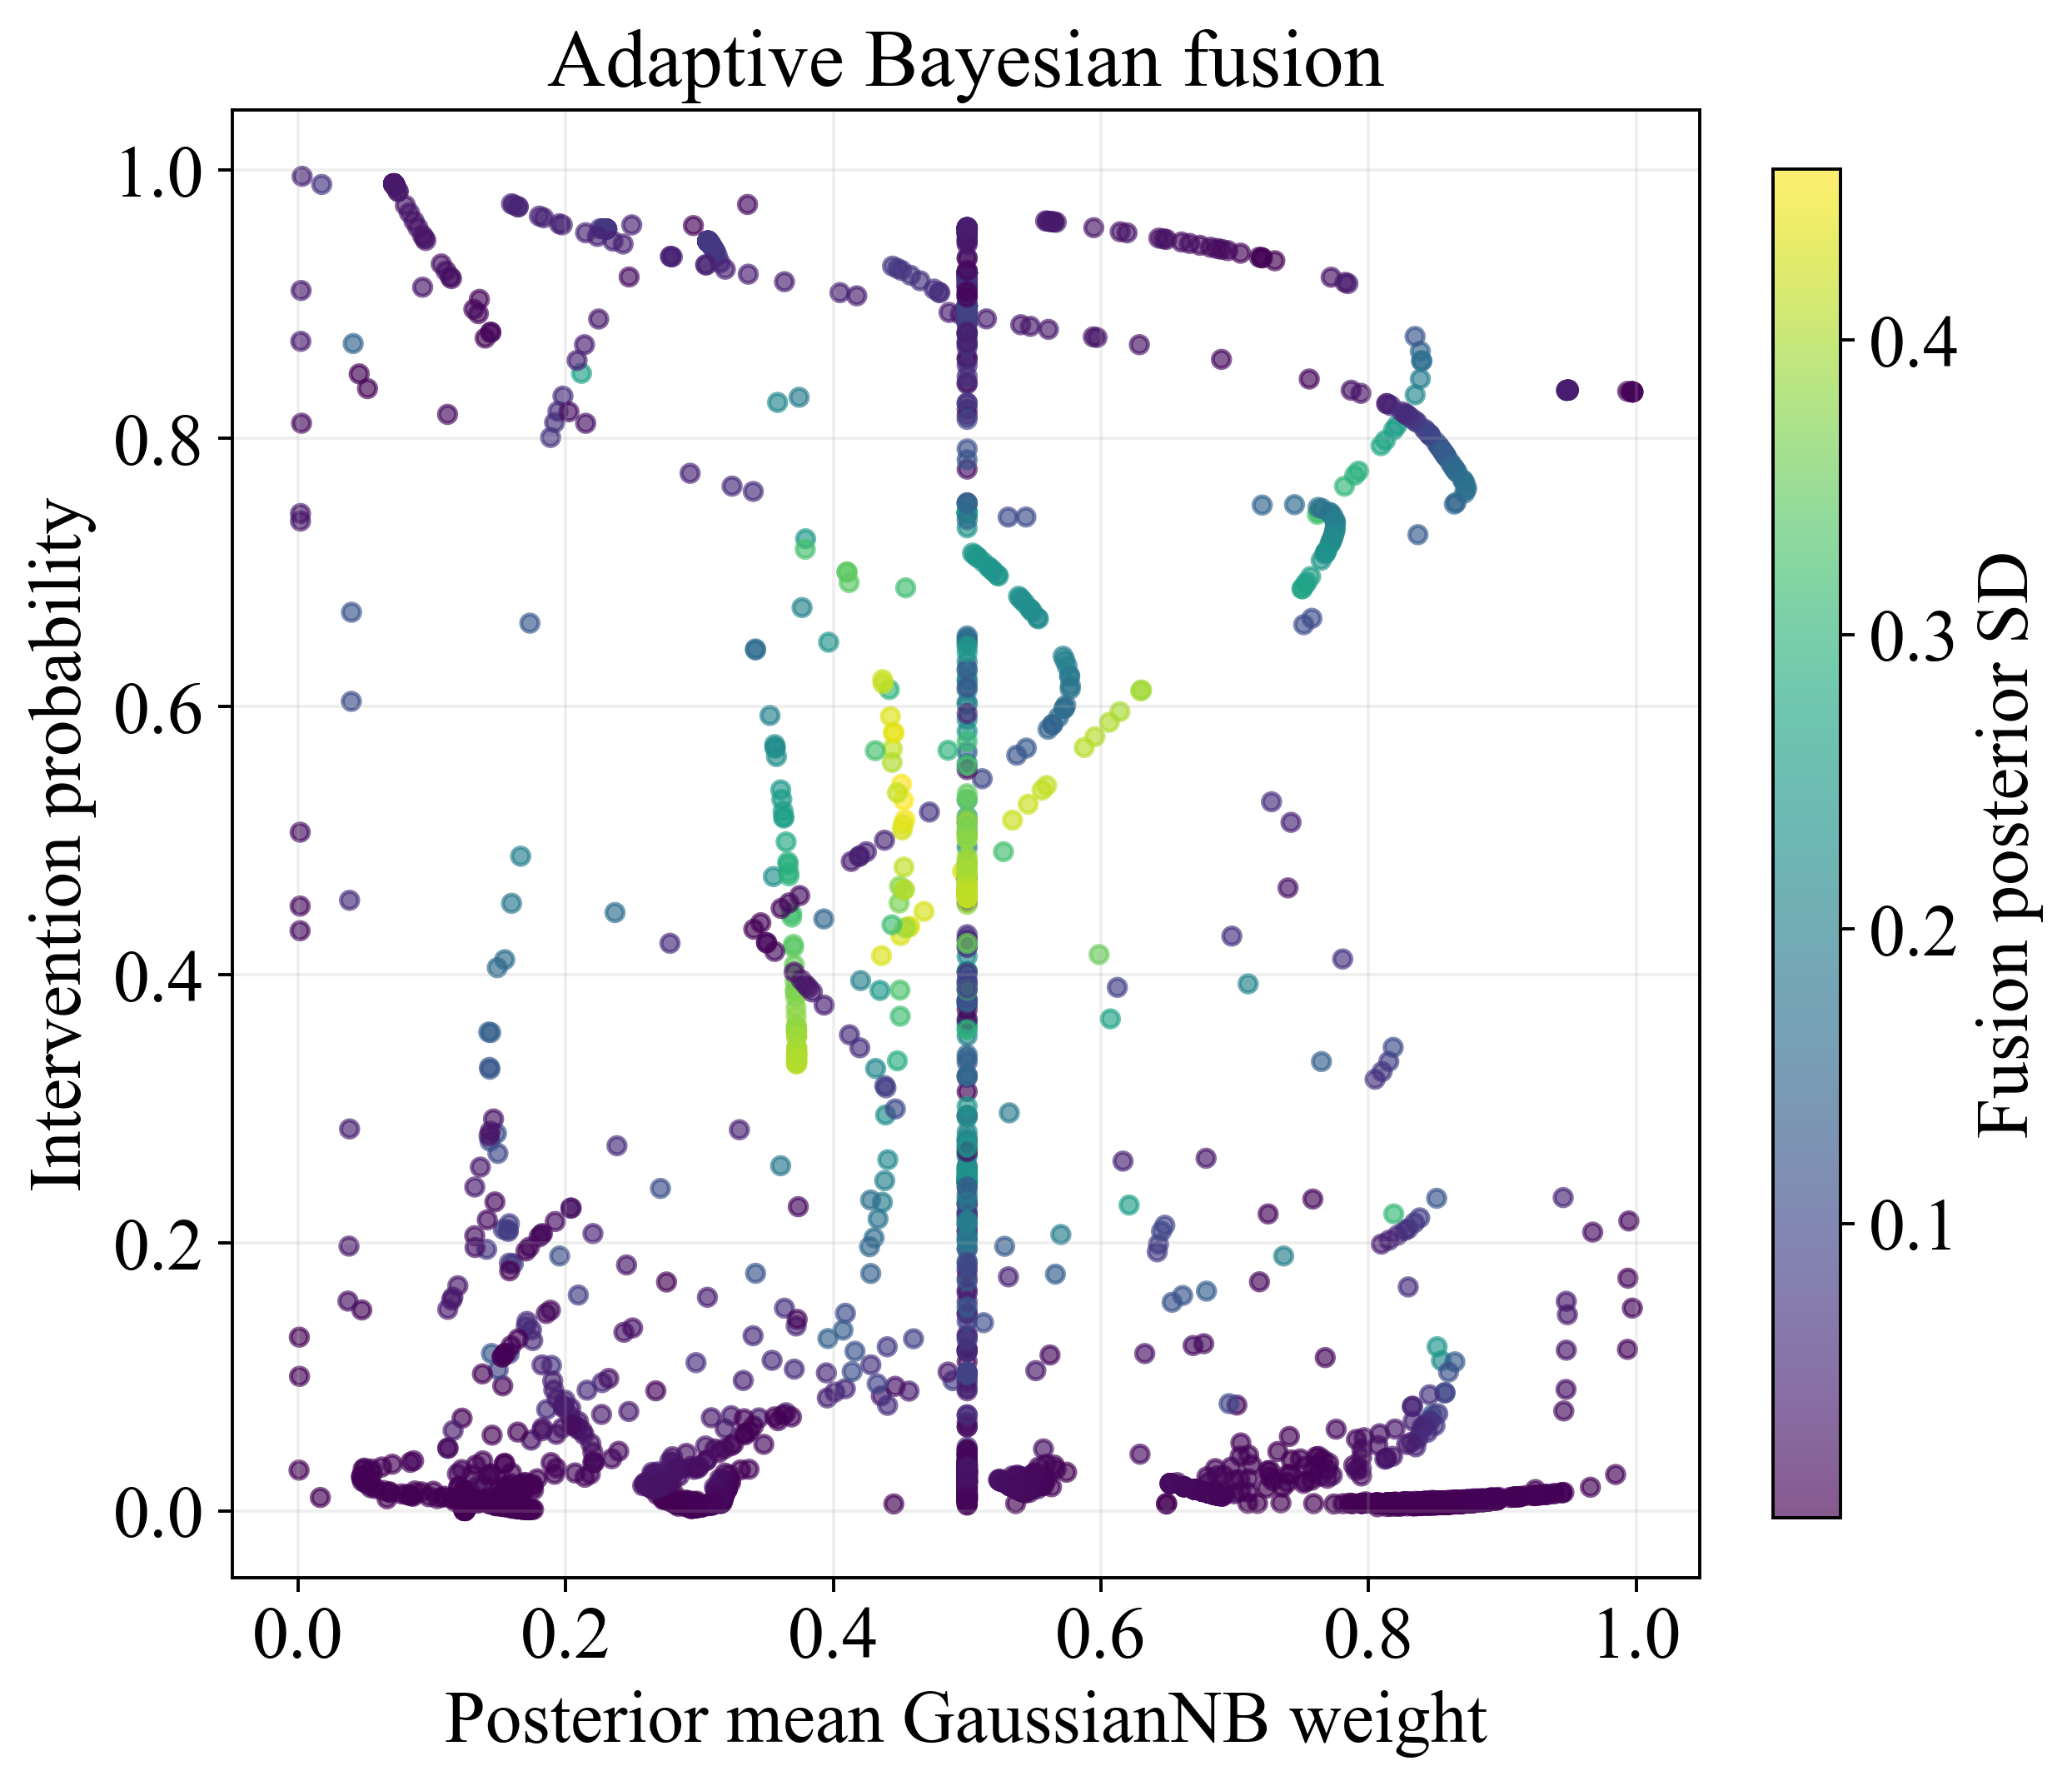

In [49]:
full_evidence = current_oof[current_oof.model.eq("HBAF")]
fig, axis = plt.subplots(figsize=(178/25.4, 170/25.4), dpi=350, layout="constrained")
points = axis.scatter(full_evidence.gate_mean, full_evidence.probability,
    c=full_evidence.uncertainty, cmap="viridis", s=18, alpha=.65)
axis.set_xlabel("Posterior mean GaussianNB weight")
axis.set_ylabel("Intervention probability")
axis.set_title("Adaptive Bayesian fusion")
fig.colorbar(points, ax=axis, label="Fusion posterior SD", shrink=.7)
axis.set_box_aspect(1)
axis.grid(alpha=.2)
fig.savefig(FIGURES / "04_hbaf_current_fusion.png", dpi=350)
fig.savefig(FIGURES / "04_hbaf_current_fusion.pdf", dpi=350)
plt.show()
plt.close(fig)

Each point is a held-path prediction in one repeat. This diagnostic demonstrates the fitted mechanism only; it does not establish benefit. The quantitative comparison and ablations remain binding.

In [50]:
for number, fitted in enumerate(CURRENT_FITS, 1):
    path = MODEL_DIR / f"outer_{number:02d}.pkl"
    with path.open("wb") as handle:
        cloudpickle.dump(fitted, handle)
    CURRENT_RUNTIME[number-1]["model_size_mb"] = path.stat().st_size / 1024**2
save_current_evidence()
assert len(CURRENT_FITS) == 15

## Fixed-posterior approximation sensitivity

Does the local Gaussian approximation represent the training posterior adequately? This diagnostic fixes the R1/F1 learned hyperparameters and uses only its cached cross-fitted training evidence. A heavy-tailed proposal covers the distinct verified modes. It does not retrain, replace any frozen predictions, or use assessment labels. Proposal weights are numerical integration weights, not manually chosen fusion coefficients.

In [51]:
from scipy.stats import multivariate_t

diag_fit = next(item for item in CURRENT_FITS
    if item["partition"]["repeat"] == 1 and item["partition"]["fold"] == 1)
diag_part, diag_gate = diag_fit["partition"], diag_fit["fusion"]["full"]
diag_indices = diag_part["fit"]
diag_key = (tuple(diag_indices), diag_part["seed"], diag_part["fold"])
assert diag_key in CROSSFIT_EXPERTS and diag_gate.prior_sd_ > 0
diag_probability = CROSSFIT_EXPERTS[diag_key][0]
diag_matrix = diag_gate.design(diag_probability)
_, diag_codes = np.unique(groups[diag_indices], return_inverse=True)
diag_membership = np.eye(diag_codes.max() + 1)[diag_codes]
diag_design = np.column_stack([
    diag_gate.prior_sd_ * diag_matrix, diag_gate.tau_ * diag_membership])
diag_p = np.clip(diag_probability, EPSILON, 1 - EPSILON)
diag_y = y_all[diag_indices, None]
diag_events = diag_y*np.log(diag_p) + (1-diag_y)*np.log1p(-diag_p)
diag_arguments = (diag_design, diag_events[:, 0], diag_events[:, 1])
diag_modes, diag_proposals = [], []
for intercept in (-1.0, 0.0, 1.0):
    initial = np.zeros(diag_design.shape[1]); initial[0] = intercept
    result = minimize(lambda value: mixture_posterior(
        value, *diag_arguments)[:2], initial, jac=True, method="BFGS",
        options={"gtol": 1e-6, "maxiter": 400})
    value, gradient, hessian = mixture_posterior(result.x, *diag_arguments)
    if not np.isfinite(value) or np.max(np.abs(gradient)) > 1e-4:
        continue
    if any(np.allclose(result.x, mode, atol=1e-6, rtol=1e-5)
           for mode in diag_modes):
        continue
    try:
        covariance = cho_solve(cho_factor(hessian), np.eye(len(result.x)))
    except np.linalg.LinAlgError:
        continue
    diag_modes.append(result.x.copy())
    diag_proposals.append(multivariate_t(result.x, covariance, df=5))
assert diag_proposals


In [52]:
diag_rng = np.random.default_rng(20260917)
diag_draw_count = 4096
diag_component = diag_rng.integers(len(diag_proposals), size=diag_draw_count)
diag_draws = np.empty((diag_draw_count, diag_design.shape[1]))
for component, proposal in enumerate(diag_proposals):
    selected = np.flatnonzero(diag_component == component)
    if len(selected):
        diag_draws[selected] = np.asarray(proposal.rvs(
            size=len(selected), random_state=diag_rng)).reshape(len(selected), -1)
diag_log_proposal = logsumexp(np.stack([
    proposal.logpdf(diag_draws) for proposal in diag_proposals
]), axis=0) - np.log(len(diag_proposals))
diag_eta = diag_design @ diag_draws.T
diag_log_target = np.logaddexp(
    -np.logaddexp(0, diag_eta) + diag_events[:, :1],
    -np.logaddexp(0, -diag_eta) + diag_events[:, 1:2],
).sum(axis=0) - 0.5*np.sum(diag_draws**2, axis=1)
diag_log_weight = diag_log_target - diag_log_proposal
assert np.isfinite(diag_log_weight).all()
diag_weight = np.exp(diag_log_weight - logsumexp(diag_log_weight))
diag_ess = float(1.0 / np.sum(diag_weight**2))
assert np.isclose(diag_weight.sum(), 1.0)


In [53]:
diag_beta = diag_gate.prior_sd_ * diag_draws[:, :3]
diag_new_effect = diag_rng.normal(0.0, diag_gate.tau_, size=diag_draw_count)
diag_weight_draws = expit(diag_matrix @ diag_beta.T + diag_new_effect)
diag_difference = diag_probability[:, 1] - diag_probability[:, 0]
diag_risk_draws = diag_probability[:, :1] + diag_difference[:, None]*diag_weight_draws
diag_mean = diag_risk_draws @ diag_weight
diag_variance = (diag_risk_draws**2) @ diag_weight - diag_mean**2
assert diag_variance.min() >= -1e-10
diag_sd = np.sqrt(np.maximum(diag_variance, 0.0))
diag_mc_se = np.sqrt(
    ((diag_risk_draws - diag_mean[:, None])**2) @ (diag_weight**2))
diag_reference = diag_gate.predict(diag_probability)
diag_table = pd.DataFrame([{
    "Boundary": "R1/F1 training; fixed hyperparameters", "n": len(diag_indices),
    "Distinct modes": len(diag_modes), "Proposal draws": diag_draw_count,
    "Importance ESS": diag_ess, "Largest normalized weight": diag_weight.max(),
    "Mean-risk RMSE": np.sqrt(np.mean((diag_mean-diag_reference["probability"])**2)),
    "Maximum mean-risk difference": np.max(np.abs(diag_mean-diag_reference["probability"])),
    "Posterior-SD RMSE": np.sqrt(np.mean((diag_sd-diag_reference["uncertainty"])**2)),
    "Median Monte Carlo SE": np.median(diag_mc_se),
    "Maximum Monte Carlo SE": diag_mc_se.max(),
}])
display_grouped_tables(diag_table, ["Boundary", "n"], {
    "Conditional posterior support": ["Distinct modes", "Proposal draws",
        "Importance ESS", "Largest normalized weight"],
    "Sensitivity to posterior approximation": ["Mean-risk RMSE",
        "Maximum mean-risk difference", "Posterior-SD RMSE",
        "Median Monte Carlo SE", "Maximum Monte Carlo SE"]})
diag_table.to_csv(TABLES / "hbaf_current_posterior_diagnostic.csv", index=False)


#### Conditional posterior support

,Boundary,n,Distinct modes,Proposal draws,Importance ESS,Largest normalized weight
0,R1/F1 training; fixed hyperparameters,371,2,4096,12.8599,0.1894


#### Sensitivity to posterior approximation

,Boundary,n,Mean-risk RMSE,Maximum mean-risk difference,Posterior-SD RMSE,Median Monte Carlo SE,Maximum Monte Carlo SE
0,R1/F1 training; fixed hyperparameters,371,0.0620,0.1392,0.0302,0.0312,0.0628


Low importance ESS makes posterior agreement inconclusive; it cannot validate the Laplace credible intervals. Even high ESS would not prove that three starts found every mode. Reported uncertainty is conditional single-mode Laplace fusion uncertainty with empirical-Bayes hyperparameters, not total calibrated epistemic uncertainty. The frozen held-out predictions remain unchanged.

The current calibrated experts reproduce Notebook 03 probability predictions up to numerical clipping, but thresholds are selected using a deeper exclusion layer. Consequently a large MCC improvement over the current matched parent must not be described as the same improvement over the original Notebook 03 model. Both remain visible in the final comparison.

## Summary

The HBAF candidate combines two calibrated experts with a conditional Bayesian competence posterior and marginalization of unseen experiment effects. It is a terminal decision-support model; neither physical degradation-state identification nor causal early superiority is claimed. All selection and fitting use development groups only. The outcome remains provisional until the current Notebook 05 evaluates the prespecified Bayesian ablations and uncertainty-aware decisions. Internal and external descriptive evaluation cannot rescue a failed development result.